In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import warnings



from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

Step 1: Oil + Look-alike + No-Oil datasets ko training ke liye organize karenge.

Step 2: Images ko suitable size/patches mein preprocess karenge.

Step 3: First baseline model train karenge.

Step 4: Prediction dekhenge and metrics calculate karenge.

Step 5: Phir model improve karenge

**Libraries install/import**

GPU check

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


Image aur mask paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.path.exists("/content/drive/MyDrive/SIH26143_Oil_Spill")

True

In [ ]:
import os

IMAGE_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/images/Oil"
MASK_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/masks_extracted/Oil/Mask_oil"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(".tif")
])

print("Total images:", len(image_files))

Total images: 1200


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**image + mask pairing and dataset split**

In [ ]:
import os
from sklearn.model_selection import train_test_split

IMAGE_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/images/Oil"
MASK_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/masks_extracted/Oil/Mask_oil"

image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith(".tif")
])

train_files, val_files = train_test_split(
    image_files,
    test_size=0.15,
    random_state=42
)

print("Total:", len(image_files))
print("Training:", len(train_files))
print("Validation:", len(val_files))

Total: 1200
Training: 1020
Validation: 180


**Dataset + DataLoader**

reading SAR TIFF+corresponding  mask, normalizing it, resizing and divding it in batches

->bridge between your dataset and the neural network.

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import os


class OilSpillDataset(Dataset):

    def __init__(self, image_files, image_dir, mask_dir, size=512):
        self.image_files = image_files
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.size = size

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        filename = self.image_files[idx]

        image_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)

        # Read SAR image: 2 channels = VV and VH
        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        # Read binary mask
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)

        # Normalize VV and VH separately
        for c in range(image.shape[0]):
            mean = image[c].mean()
            std = image[c].std()
            image[c] = (image[c] - mean) / (std + 1e-8)

        # Convert to tensors
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)

        # Add channel dimension to mask
        mask = mask.unsqueeze(0)

        # Resize image
        image = F.interpolate(
            image.unsqueeze(0),
            size=(self.size, self.size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # Resize mask
        mask = F.interpolate(
            mask.unsqueeze(0),
            size=(self.size, self.size),
            mode="nearest"
        ).squeeze(0)

        # Ensure mask is 0/1
        mask = (mask > 0.5).float()

        return image, mask

creating datsets and loaders

In [ ]:
train_dataset = OilSpillDataset(
    train_files,
    IMAGE_DIR,
    MASK_DIR,
    size=512
)

val_dataset = OilSpillDataset(
    val_files,
    IMAGE_DIR,
    MASK_DIR,
    size=512
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training samples: 1020
Validation samples: 180
Training batches: 255
Validation batches: 45


### Data Loading Optimization: `num_workers`

To improve file loading speed for your training dataset, you can increase the `num_workers` parameter in your `DataLoader`s. This allows parallel data loading and preprocessing, preventing the CPU from becoming a bottleneck during data fetching.

Here, we'll set `num_workers` to utilize available CPU cores, which is typically a good starting point.

In [ ]:
import os

# Get the number of CPU cores available, or use a default like 4
num_cpu_cores = os.cpu_count()
NUM_WORKERS = num_cpu_cores if num_cpu_cores else 4

print(f"Setting num_workers to: {NUM_WORKERS}")

# Redefine DataLoaders with increased num_workers
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True # Use pin_memory for faster data transfer to GPU if available
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True # Use pin_memory for faster data transfer to GPU if available
)

print("DataLoaders redefined with optimized num_workers.")
print("Training batches (new):", len(train_loader))
print("Validation batches (new):", len(val_loader))

Setting num_workers to: 2
DataLoaders redefined with optimized num_workers.
Training batches (new): 255
Validation batches (new): 45


In [ ]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape :", masks.shape)

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Images shape: torch.Size([4, 2, 512, 512])
Masks shape : torch.Size([4, 1, 512, 512])


**U-Net model**

The U-Net is a convolutional neural network (CNN) architecture designed for fast and precise image segmentation. It gets its name because its structural layout forms the shape of the letter "U".In geospatial analysis (using tools like Rasterio), U-Net is the industry-standard model for extracting features from satellite imagery—such as mapping buildings, detecting roads, or isolating crop boundaries from VV and VH radar data.

**What is the U-Net Architecture?**

The network is split into two symmetrical halves that form the "U" shape:

**The Contracting Path (Left Side / Encoder):**  This acts like a traditional CNN. It repeatedly applies convolutions and pooling to compress the image, reducing its spatial size (width and height) while extracting deep, high-level features (like textures, shapes, and objects).

**The Expanding Path (Right Side / Decoder):** This path does the opposite. It upsamples the features to project them back to the original image size, creating a pixel-by-pixel map (the segmentation mask) that matches your input image exactly.

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        # Output: 1 channel = oil probability
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)

        e2 = self.enc2(self.pool(e1))

        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print("Device:", device)
print("Model created successfully.")

Device: cuda
Model created successfully.


**`LOSS function`**

A loss function is a mathematical formula that calculates how wrong a machine learning model's guesses are.

**1. BCE (Binary Cross-Entropy Loss)**
BCE looks at your image on a strict, independent pixel-by-pixel basis.
It evaluates every single pixel one at a time and asks: "Did the model correctly guess if this specific pixel is a target (1) or background (0)?" It penalizes the model based on how confident it was in its wrong guess.

**2. Dice LossDice**

 Loss looks at the image as a whole, focusing entirely on how well shapes overlap.
 It measures the overlap between the model's predicted shape and the actual true shape. It is derived from the Dice Coefficient, which calculates the intersection of two shapes divided by their total combined area.

The Formula Concept: \(\text{Dice Loss} = 1 - \frac{2 \times \text{Overlap Area}}{\text{Predicted Area} + \text{True Area}}\)

TOTAL LOSS=BCE+ DICE LOSS

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (
            2 * intersection + self.smooth
        ) / (
            probs.sum() +
            targets.sum() +
            self.smooth
        )

        return 1 - dice

In [ ]:
bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()


def combined_loss(pred, target):
    return (
        0.5 * bce_loss(pred, target)
        +
        0.5 * dice_loss(pred, target)
    )

**OPTIMIZER**

Adam is what adjusts the neural-network weights after the model makes mistakes

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer ready.")

Optimizer ready.


**Training**

An **epoch** (pronounced "epic" or "ee-pock") is one complete cycle through your entire training dataset during the training of a machine learning model.

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):

    # -------------------
    # Training
    # -------------------
    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # -------------------
    # Validation
    # -------------------
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )


evaluation

In [ ]:
import torch
import numpy as np

model.eval()

dice_scores = []
iou_scores = []
precision_scores = []
recall_scores = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Flatten
        preds_flat = preds.view(-1)
        masks_flat = masks.view(-1)

        # Confusion values
        tp = (preds_flat * masks_flat).sum().item()
        fp = (preds_flat * (1 - masks_flat)).sum().item()
        fn = ((1 - preds_flat) * masks_flat).sum().item()

        # Dice
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)

        # IoU
        iou = tp / (tp + fp + fn + 1e-8)

        # Precision
        precision = tp / (tp + fp + 1e-8)

        # Recall
        recall = tp / (tp + fn + 1e-8)

        dice_scores.append(dice)
        iou_scores.append(iou)
        precision_scores.append(precision)
        recall_scores.append(recall)

print("Dice Score :", np.mean(dice_scores))
print("IoU Score  :", np.mean(iou_scores))
print("Precision  :", np.mean(precision_scores))
print("Recall     :", np.mean(recall_scores))

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Dice Score : 0.0
IoU Score  : 0.0
Precision  : 0.0
Recall     : 0.0


**TESTING- VALIDATION ON A RANDOM IMAGE**

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


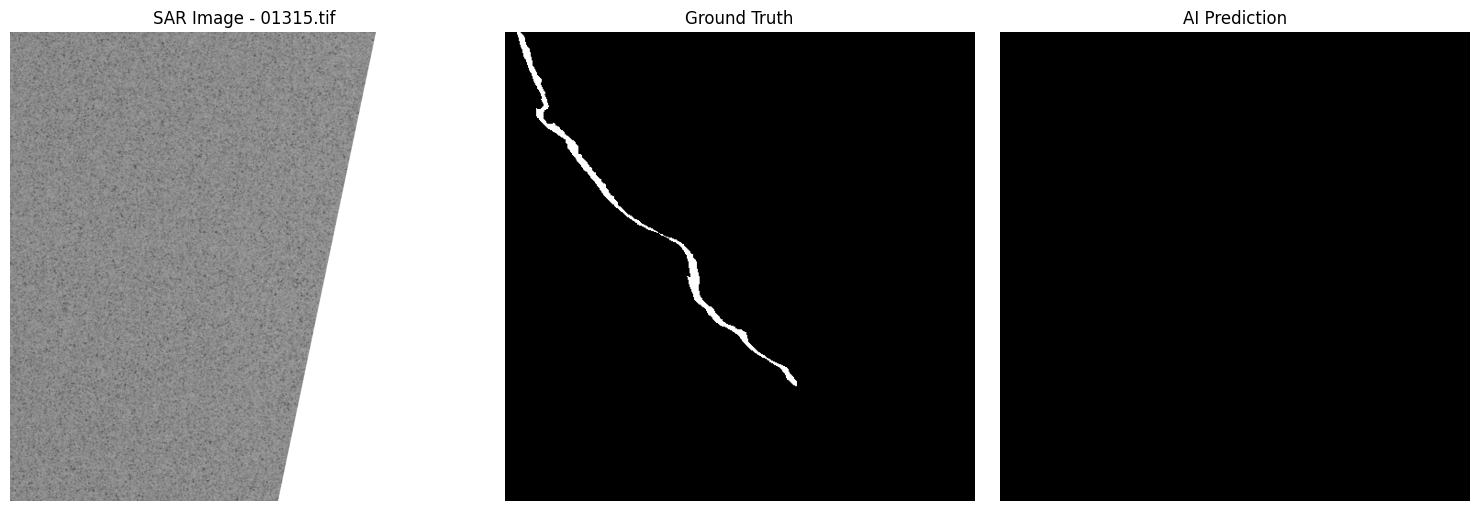

In [ ]:
import torch
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Take one validation image
filename = val_files[0]

image_path = os.path.join(IMAGE_DIR, filename)
mask_path = os.path.join(MASK_DIR, filename)

# Read SAR image
with rasterio.open(image_path) as src:
    image = src.read().astype(np.float32)

# Read ground-truth mask
with rasterio.open(mask_path) as src:
    mask = src.read(1).astype(np.float32)

# Normalize VV and VH
for c in range(image.shape[0]):
    mean = image[c].mean()
    std = image[c].std()
    image[c] = (image[c] - mean) / (std + 1e-8)

# Convert to tensor
image_tensor = torch.from_numpy(image).unsqueeze(0).to(device)

# Resize to model input
image_tensor = torch.nn.functional.interpolate(
    image_tensor,
    size=(512, 512),
    mode="bilinear",
    align_corners=False
)

# Predict
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    probability = torch.sigmoid(output)
    prediction = (probability > 0.5).float()

# Convert to numpy
prediction = prediction.squeeze().cpu().numpy()

# Resize actual mask to same size for visualization
mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0)

mask_resized = torch.nn.functional.interpolate(
    mask_tensor,
    size=(512, 512),
    mode="nearest"
).squeeze().numpy()

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[0], cmap="gray")
axes[0].set_title(f"SAR Image - {filename}")
axes[0].axis("off")

axes[1].imshow(mask_resized, cmap="gray")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(prediction, cmap="gray")
axes[2].set_title("AI Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/SIH26143_Oil_Spill/models/unet_baseline.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: /content/drive/MyDrive/SIH26143_Oil_Spill/models/unet_baseline.pth


# **MOVING TO NEXT STEP->Oil + Look-alike + No-Oil → U-Net → oil mask**

**Create the combined dataset**

In [ ]:
import os
import numpy as np
import rasterio
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Paths
OIL_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/images/Oil"
LOOKALIKE_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/images/Lookalike"
NO_OIL_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/images/No_oil"

OIL_MASK_DIR = "/content/drive/MyDrive/SIH26143_Oil_Spill/raw/masks_extracted/Oil/Mask_oil"

# Get filenames
oil_files = sorted([f for f in os.listdir(OIL_DIR) if f.endswith(".tif")])
lookalike_files = sorted([f for f in os.listdir(LOOKALIKE_DIR) if f.endswith(".tif")])
no_oil_files = sorted([f for f in os.listdir(NO_OIL_DIR) if f.endswith(".tif")])

print("Oil:", len(oil_files))
print("Look-alike:", len(lookalike_files))
print("No-Oil:", len(no_oil_files))

Oil: 1200
Look-alike: 685
No-Oil: 685


**Train test split**

In [ ]:
oil_train, oil_val = train_test_split(
    oil_files,
    test_size=0.15,
    random_state=42
)

look_train, look_val = train_test_split(
    lookalike_files,
    test_size=0.15,
    random_state=42
)

nooil_train, nooil_val = train_test_split(
    no_oil_files,
    test_size=0.15,
    random_state=42
)

print("Training:")
print("  Oil:", len(oil_train))
print("  Look-alike:", len(look_train))
print("  No-Oil:", len(nooil_train))

print("\nValidation:")
print("  Oil:", len(oil_val))
print("  Look-alike:", len(look_val))
print("  No-Oil:", len(nooil_val))

Training:
  Oil: 1020
  Look-alike: 582
  No-Oil: 582

Validation:
  Oil: 180
  Look-alike: 103
  No-Oil: 103


**New Dataset class**

In [ ]:
class CombinedOilSpillDataset(Dataset):

    def __init__(
        self,
        oil_files,
        lookalike_files,
        nooil_files,
        oil_dir,
        lookalike_dir,
        nooil_dir,
        oil_mask_dir,
        size=512
    ):
        self.size = size
        self.records = []

        # Oil samples
        for f in oil_files:
            self.records.append(
                ("oil", f, oil_dir)
            )

        # Look-alike samples
        for f in lookalike_files:
            self.records.append(
                ("negative", f, lookalike_dir)
            )

        # No-oil samples
        for f in nooil_files:
            self.records.append(
                ("negative", f, nooil_dir)
            )

        self.oil_mask_dir = oil_mask_dir

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        category, filename, image_dir = self.records[idx]

        image_path = os.path.join(image_dir, filename)

        # Read SAR image
        with rasterio.open(image_path) as src:
            image = src.read().astype(np.float32)

        # Normalize VV and VH separately
        for c in range(image.shape[0]):
            mean = image[c].mean()
            std = image[c].std()

            image[c] = (
                image[c] - mean
            ) / (std + 1e-8)

        # --------------------------------
        # Create target mask
        # --------------------------------

        if category == "oil":

            mask_path = os.path.join(
                self.oil_mask_dir,
                filename
            )

            with rasterio.open(mask_path) as src:
                mask = src.read(1).astype(np.float32)

        else:

            # Look-alike / No-Oil = no oil
            mask = np.zeros(
                (2048, 2048),
                dtype=np.float32
            )

        # Convert to tensors
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0)

        # Resize image
        image = F.interpolate(
            image.unsqueeze(0),
            size=(self.size, self.size),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # Resize mask
        mask = F.interpolate(
            mask.unsqueeze(0),
            size=(self.size, self.size),
            mode="nearest"
        ).squeeze(0)

        mask = (mask > 0.5).float()

        return image, mask

creating new folders

In [ ]:
train_dataset = CombinedOilSpillDataset(
    oil_train,
    look_train,
    nooil_train,
    OIL_DIR,
    LOOKALIKE_DIR,
    NO_OIL_DIR,
    OIL_MASK_DIR,
    size=512
)

val_dataset = CombinedOilSpillDataset(
    oil_val,
    look_val,
    nooil_val,
    OIL_DIR,
    LOOKALIKE_DIR,
    NO_OIL_DIR,
    OIL_MASK_DIR,
    size=512
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Total training samples:", len(train_dataset))
print("Total validation samples:", len(val_dataset))

now we training the same model. THIS IS CALLED FINE-TUNING/ COUNTINUED TRAINING

In [ ]:
model.train()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5
)

EPOCHS = 5

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = combined_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = combined_loss(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"| Train Loss: {train_loss:.4f} "
        f"| Val Loss: {val_loss:.4f}"
    )

    # Save model checkpoint after each epoch
    checkpoint_path = os.path.join(
        os.path.dirname(MODEL_PATH),
        f"unet_checkpoint_epoch_{(epoch+1):02d}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Saved checkpoint: {checkpoint_path}")

In [ ]:
# Identify and remove the corrupted file from the dataset lists
corrupted_file = '00346.tif'

print(f"Cleaning dataset: searching for {corrupted_file}...")

# Check all training lists
if corrupted_file in oil_train:
    oil_train.remove(corrupted_file)
    print(f"Removed {corrupted_file} from oil_train")
if corrupted_file in look_train:
    look_train.remove(corrupted_file)
    print(f"Removed {corrupted_file} from look_train")
if corrupted_file in nooil_train:
    nooil_train.remove(corrupted_file)
    print(f"Removed {corrupted_file} from nooil_train")

# Re-initialize the dataset and loaders with the cleaned lists
train_dataset = CombinedOilSpillDataset(
    oil_train,
    look_train,
    nooil_train,
    OIL_DIR,
    LOOKALIKE_DIR,
    NO_OIL_DIR,
    OIL_MASK_DIR,
    size=512
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

print(f"Dataset cleaned. New total training samples: {len(train_dataset)}")
print("You can now run the training cell (EUxxHZHlULZs) again.")

The training was interrupted after Epoch 1 completed. To resume the training, the loop will be restarted from Epoch 2 onwards.

Rerun due to kernel restart

In [ ]:
import torch
import torch.nn as nn
import os
from google.colab import drive

# 1. Ensure Drive is mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# 2. Re-define the Architecture
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.final = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.final(d1)

# 3. Define Loss Functions
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs, targets = probs.view(-1), targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(pred, target):
    return 0.5 * bce_loss(pred, target) + 0.5 * dice_loss(pred, target)

# 4. Re-initialize and Load Weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
MODEL_PATH = "/content/drive/MyDrive/SIH26143_Oil_Spill/models/unet_baseline.pth"

if os.path.exists(MODEL_PATH):
    try:
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print("Successfully loaded baseline weights.")
    except Exception as e:
        print(f"Error loading weights: {e}")
else:
    print(f"File not found at {MODEL_PATH}.")

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)
print(f"Model and Loss functions ready on {device}. Please run the Training cell (EUxxHZHlULZs) next.")